In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

using the above codes import essential libraries to load and  analysis data

In [2]:
#Data Loading & Date Parsing
df = pd.read_csv("../data/sudan.csv")
# Add country column
df["Country"] = "Sudan"

# Create datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


In [3]:
#Cleaning & Summary 1: Replace -999
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,2026-03-27,3
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28,3
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29,3
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30,3


In [4]:
#Check duplicates
df.duplicated().sum()


np.int64(0)

#the result np.int64(0) This means:

#0 → there are no duplicate rows in your dataset
#np.int64 → just the data type (a number format from NumPy, nothing to worry about)

In [5]:
#If there WERE duplicates (for your knowledge)You would remove them like this:
df = df.drop_duplicates()
#so the result is nothing or no duplicate rows

In [6]:
#Summary statistics: count, mmean, min, 25%, 50%, 75%, max and std.
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


In [7]:
# Missing values and the result shows with no missing values
missing = df.isna().sum()
percent = (missing / len(df)) * 100
pd.DataFrame({"Missing": missing, "Percent": percent})

,Missing,Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [8]:
#Outlier Detection: Z-score
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
outliers

T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64

In [9]:
##Outlier Detection Z-score
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
outliers

T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64

In [10]:
#Handle Missing Values
#df.fillna(method="ffill", inplace=True)
df = df.dropna(thresh=int(0.7 * df.shape[1]))



In [11]:
#Save cleaned data
df.to_csv("../data/sudan_clean.csv", index=False)

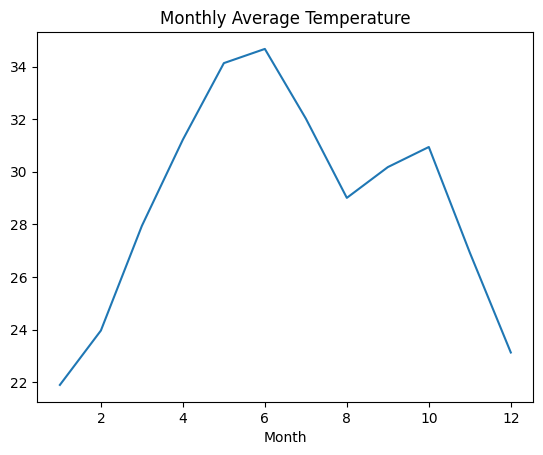

In [12]:
#Time Series Analysis, Monthly Temperature
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot()
plt.title("Monthly Average Temperature")
plt.show()

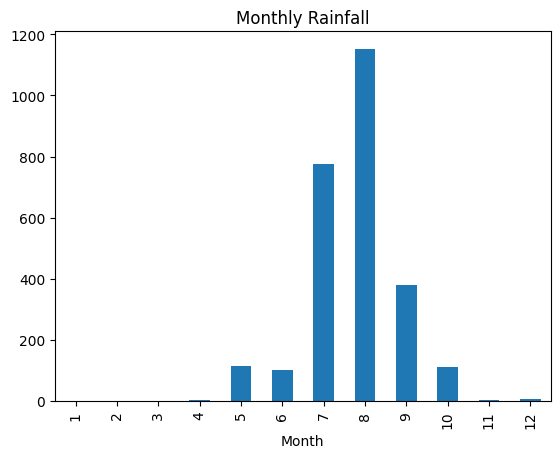

In [13]:
#Rainfall
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

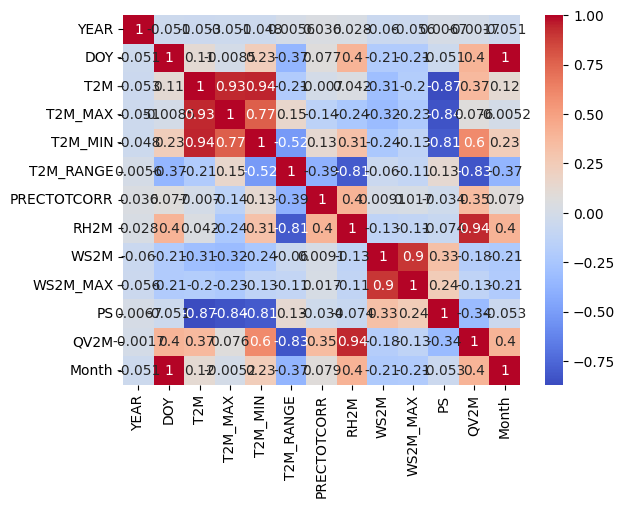

In [14]:
#Correlation Analysis
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

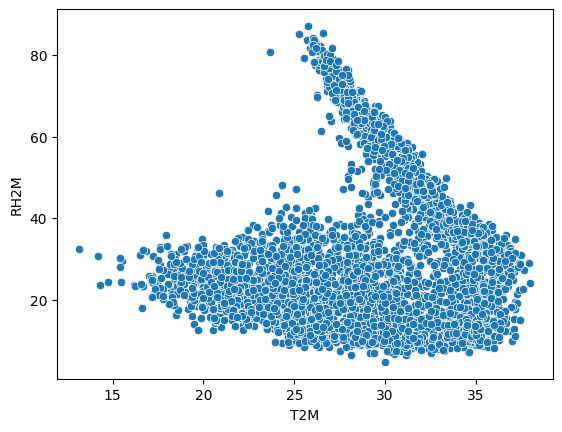

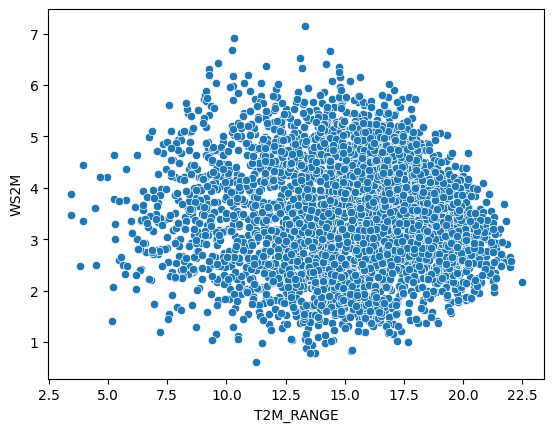

In [15]:
#Scatter plots
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

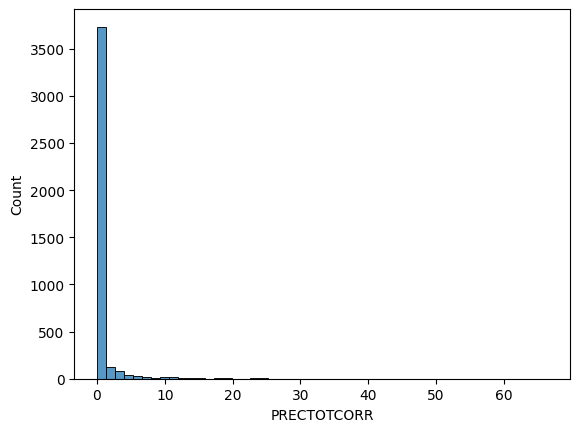

In [16]:
#Distribution Analysis, Histogram
sns.histplot(df["PRECTOTCORR"], bins=50)
plt.show()

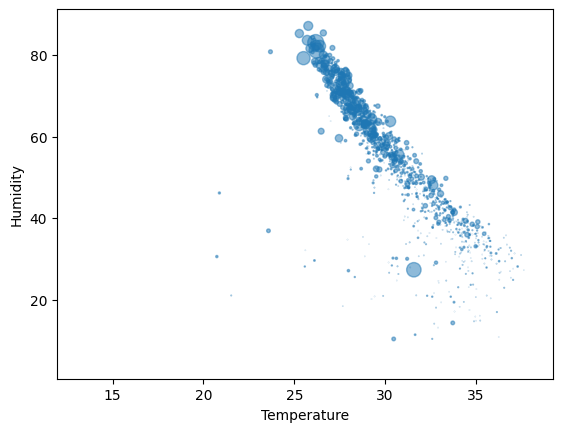

In [17]:
#Bubble chart#
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 2,
    alpha=0.5
)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()